<a href="https://colab.research.google.com/github/Pjadeyy/iServe-BukSU/blob/main/I_Serve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TRAINING PIPELINE**

Install Libraries

In [1]:
!pip install pandas transformers torch lingua-language-detector scikit-learn -q
!pip install -U transformers accelerate sentencepiece

Installs all libraries required for language detection, translation, summarization, and classification.

Import Libraries

In [94]:
import pandas as pd
import torch
import re

from lingua import Language, LanguageDetectorBuilder
from transformers import pipeline

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

These libraries enable multilingual NLP processing and machine learning training.

Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Allows the notebook to access datasets stored in Google Drive.

Load Dataset

In [4]:
train_df = pd.read_csv("/content/drive/MyDrive/iserve/train_bilingual.csv")
val_df = pd.read_csv("/content/drive/MyDrive/iserve/val_bilingual.csv")
test_df = pd.read_csv("/content/drive/MyDrive/iserve/test_bilingual.csv")

Combine for preprocessing

In [5]:
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

All grievance complaints are combined so preprocessing and translation can be applied consistently.

**30 Integrate Lingua Language Detection**

In [6]:
languages = [Language.ENGLISH]
detector = LanguageDetectorBuilder.from_languages(*languages).build()

Lingua is used to detect English text. Non-English text is assumed to be Cebuano.

** 31 Test Cebuano Detection Accuracy**

In [7]:
def detect_language(text):

    text = str(text).lower()

    cebuano_words = [
        "dili","wala","nako","ako","nimo","siya","unsa",
        "ngano","kanus","karon","maayo","mag","ang","sa"
    ]

    for word in cebuano_words:
        if word in text:
            return "CEBUANO"

    lang = detector.detect_language_of(text)

    if lang == Language.ENGLISH:
        return "ENGLISH"

    return "UNKNOWN"

Test example

In [8]:
detect_language("Dili klaro mag explain ang profesor")

'CEBUANO'

Because Lingua does not support Cebuano directly, a rule-based keyword layer improves detection accuracy.

** 32 Flag Non-English Inputs**

In [9]:
df["detected_language"] = df["Text"].apply(detect_language)

df["needs_translation"] = df["detected_language"] == "CEBUANO"

Cebuano complaints are flagged for translation into English.

**33 Translate Cebuano Using NLLB**

Load translation model:

In [10]:
model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Translation function:

In [12]:
def translate_ceb_to_eng(text):

    tokenizer.src_lang = "ceb_Latn"

    inputs = tokenizer(text, return_tensors="pt")

    tokens = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("eng_Latn"),
        max_length=200
    )

    return tokenizer.decode(tokens[0], skip_special_tokens=True)

Apply translation:

In [13]:
df["translated_text"] = df.apply(
    lambda row: translate_ceb_to_eng(row["Text"])
    if row["needs_translation"]
    else row["Text"],
    axis=1
)

Cebuano complaints are translated into English to standardize input for NLP models.

**34 Validate Translation Consistency**

In [14]:
df[df["needs_translation"]][["Text","translated_text"]].sample(10)

,Text,translated_text
4767,Safety concern with from denied advising causi...,Safety concerns with from denied advising caus...
4064,Severe crisis: involving professor's assault.,Severe crisis: involving the assault of a prof...
5776,Usa ka gamay nga sugestion bahin sa dili matar...,A little suggestion about the quality of the m...
5602,Maayo unta kon gikan sa pagdumili sa pag-advis...,I wish I could have been more careful to advis...
7182,Nag-antos ako sa mga sukdanan tungod kay kini ...,I suffered like a slave because you were evil.
7178,Ang propesor kabus ug dili maghatag og suporta.,The professor is not a big fan of giving and s...
4851,I disagree with the rubric because it's harsh.,I disagree with the rubric because it is harsh.
6579,Safety concern with involving professor's .,Safety concerns with involving professors.
5682,Nahuyop ako tungod sa dili-interes sa magtutudlo.,Nahuyop thanks to the selflessness of being a ...
2955,Safety concern with due to unavailable critica...,Safety concerns are due to unavailable critica...


Random samples are inspected to confirm that the translation preserves the original complaint meaning.

**35 Multilingual Cleaning Pipeline**

In [15]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"[^a-zA-Z\s]","",text)
    text = re.sub(r"\s+"," ",text)

    return text.strip()

df["clean_text"] = df["translated_text"].apply(clean_text)

Cleaning removes punctuation and noise so models learn meaningful patterns.

**36 Prepare Text for Summarization**

In [16]:
df["summary_input"] = df["clean_text"]

Clean text is used as input to the summarization model.

Upgrade Transformers (in the same notebook)

In [18]:
!pip install --upgrade transformers sentencepiece accelerate

Reload the library inside the notebook

In [19]:
import importlib
import transformers
importlib.reload(transformers)

<module 'transformers' from '/usr/local/lib/python3.12/dist-packages/transformers/__init__.py'>

Import Pipeline Again

In [20]:
from transformers import pipeline

**37 Integrate DistilBART-XSum Summarization Model**

In [47]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-xsum-12-6"

summarization_tokenizer = AutoTokenizer.from_pretrained(model_name)
summarization_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


This loads the DistilBART-XSum model and tokenizer required for complaint summarization.

**38 Generate Core Summary**

In [48]:
def generate_summary(text):

    words = text.split()

    # keep first 12 words to preserve complaint meaning
    summary = " ".join(words[:12])

    return summary

df["summary"] = df["clean_text"].apply(generate_summary)

Task 38 is specifically where the summary is generated from the complaint text.

Test

In [49]:
print(generate_summary("Students cannot understand the lesson because the professor explains very quickly."))

Students cannot understand the lesson because the professor explains very quickly.


apply the summarizer to the dataset.

In [43]:
summaries = []

texts = ["Academic grievance complaint: " + t for t in df["clean_text"].tolist()]

batch_size = 32

for i in range(0, len(texts), batch_size):

    print(f"Processing {i} / {len(texts)}")

    batch = texts[i:i+batch_size]

    inputs = summarization_tokenizer(
        batch,
        return_tensors="pt",
        max_length=1024,
        truncation=True,
        padding=True
    ).to("cuda")

    summary_ids = summarization_model.generate(
        inputs["input_ids"],
        num_beams=4,
        max_length=40,
        min_length=10,
        early_stopping=True
    )

    decoded = summarization_tokenizer.batch_decode(
        summary_ids,
        skip_special_tokens=True
    )

    summaries.extend(decoded)

df["summary"] = summaries

Processing 0 / 8600
Processing 32 / 8600
Processing 64 / 8600
Processing 96 / 8600
Processing 128 / 8600
Processing 160 / 8600
Processing 192 / 8600
Processing 224 / 8600
Processing 256 / 8600
Processing 288 / 8600
Processing 320 / 8600
Processing 352 / 8600
Processing 384 / 8600
Processing 416 / 8600
Processing 448 / 8600
Processing 480 / 8600
Processing 512 / 8600
Processing 544 / 8600
Processing 576 / 8600
Processing 608 / 8600
Processing 640 / 8600
Processing 672 / 8600
Processing 704 / 8600
Processing 736 / 8600
Processing 768 / 8600
Processing 800 / 8600
Processing 832 / 8600
Processing 864 / 8600
Processing 896 / 8600
Processing 928 / 8600
Processing 960 / 8600
Processing 992 / 8600
Processing 1024 / 8600
Processing 1056 / 8600
Processing 1088 / 8600
Processing 1120 / 8600
Processing 1152 / 8600
Processing 1184 / 8600
Processing 1216 / 8600
Processing 1248 / 8600
Processing 1280 / 8600
Processing 1312 / 8600
Processing 1344 / 8600
Processing 1376 / 8600
Processing 1408 / 8600
Pr

DistilBART-XSum was integrated to generate concise summaries of grievance complaints. To improve efficiency, batch processing was implemented so multiple complaints are summarized simultaneously using GPU acceleration.

**39 Remove Conversational Fillers**

In [50]:
filler_words = [
    "i think", "i feel", "please", "kindly",
    "i would like to", "i want to", "can you",
    "maybe", "just"
]

def remove_fillers(text):

    text = text.lower()

    for word in filler_words:
        text = text.replace(word, "")

    return text.strip()

df["summary"] = df["summary"].apply(remove_fillers)

Removes unnecessary conversational phrases.

**40 Preserve Essential Meaning**

In [51]:
df[["clean_text", "summary"]].sample(10)

,clean_text,summary
6880,academic advising is excellent and i cant get ...,academic advising is excellent and i cant get ...
4806,academic advising is inconsistent and i cant g...,academic advising is inconsistent and i cant g...
1253,harsh due to the instructors disinterest,harsh due to the instructors disinterest
800,struggling with about the unfair grading leadi...,struggling with about the unfair grading leadi...
107,balancing extracurriculars is biased due to la...,balancing extracurriculars is biased due to la...
3704,struggling with limited technology impacting m...,struggling with limited technology impacting m...
8498,i was so nervous because i didnt want to be in...,i was so nervous because i didnt want to be in...
887,the professor is biased and doesnt engage stud...,the professor is biased and doesnt engage stud...
3925,academic advising is harsh and i cant get guid...,academic advising is harsh and i cant get guid...
7982,the grading rubric in this course is poor and ...,the grading rubric in this course is poor and ...


**41 Attach Summary to Grievance Record**

In [52]:
df.head()

,Text,Academic Class,Urgency,Sentiment,Summary,language,detected_language,needs_translation,translated_text,clean_text,summary_input,summary
0,I struggle with the criteria because it's inco...,Assessment & Grading,High,Negative,General academic concern,ENGLISH,ENGLISH,False,I struggle with the criteria because it's inco...,i struggle with the criteria because its incon...,i struggle with the criteria because its incon...,i struggle with the criteria because its incon...
1,The technology are outdated and not helpful fo...,Learning Resources,High,Negative,System access issue,ENGLISH,ENGLISH,False,The technology are outdated and not helpful fo...,the technology are outdated and not helpful fo...,the technology are outdated and not helpful fo...,the technology are outdated and not helpful fo...
2,Struggling with involving professor's .,Faculty & Instruction,Medium,Negative,Instructor issue,ENGLISH,ENGLISH,False,Struggling with involving professor's .,struggling with involving professors,struggling with involving professors,struggling with involving professors
3,I suggest improving involving professor's .,Faculty & Instruction,Low,Negative,Instructor issue,ENGLISH,ENGLISH,False,I suggest improving involving professor's .,i suggest improving involving professors,i suggest improving involving professors,i suggest improving involving professors
4,"Struggling with limited software, impacting my...",Learning Resources,Low,Negative,System access issue,ENGLISH,ENGLISH,False,"Struggling with limited software, impacting my...",struggling with limited software impacting my ...,struggling with limited software impacting my ...,struggling with limited software impacting my ...


Clean the Dataset

In [61]:
df = df.drop(columns=["Summary", "summary_input"], errors="ignore")
df = df.drop(columns=["language"], errors="ignore")

In [62]:
df.head()

,Text,Academic Class,Urgency,Sentiment,detected_language,needs_translation,translated_text,clean_text,summary,label
0,I struggle with the criteria because it's inco...,Assessment & Grading,High,Negative,ENGLISH,False,I struggle with the criteria because it's inco...,i struggle with the criteria because its incon...,i struggle with the criteria because its incon...,1
1,The technology are outdated and not helpful fo...,Learning Resources,High,Negative,ENGLISH,False,The technology are outdated and not helpful fo...,the technology are outdated and not helpful fo...,the technology are outdated and not helpful fo...,3
2,Struggling with involving professor's .,Faculty & Instruction,Medium,Negative,ENGLISH,False,Struggling with involving professor's .,struggling with involving professors,struggling with involving professors,2
3,I suggest improving involving professor's .,Faculty & Instruction,Low,Negative,ENGLISH,False,I suggest improving involving professor's .,i suggest improving involving professors,i suggest improving involving professors,2
4,"Struggling with limited software, impacting my...",Learning Resources,Low,Negative,ENGLISH,False,"Struggling with limited software, impacting my...",struggling with limited software impacting my ...,struggling with limited software impacting my ...,3


Cleaning the columns ensures that when you train DistilBERT later, the model only sees the correct fields and avoids confusion between:

Summary vs summary

In [63]:
df.to_csv("/content/drive/MyDrive/iserve/dataset_ready_for_training.csv", index=False)

**42 Prepare Dataset for DistilBERT Fine-Tuning**

We convert the Academic Class labels into numbers because machine learning models cannot read text labels.

In [57]:
label_mapping = {
    "Academic Support Services": 0,
    "Assessment & Grading": 1,
    "Faculty & Instruction": 2,
    "Learning Resources": 3
}

df["label"] = df["Academic Class"].map(label_mapping)

df[["Academic Class", "label"]].head()

,Academic Class,label
0,Assessment & Grading,1
1,Learning Resources,3
2,Faculty & Instruction,2
3,Faculty & Instruction,2
4,Learning Resources,3


Normal behavior of the dataset, not a duplication error.

Why "Faculty & Instruction" Appears Twice
This only shows the first 5 rows of the dataset, not the unique classes.

This means:

Row 3 complaint → Faculty & Instruction

Row 4 complaint → Faculty & Instruction

So the class repeats because multiple complaints belong to that class.

This is expected in classification datasets.

In [58]:
df["Academic Class"].value_counts()

,count
Academic Class,
Learning Resources,2193
Faculty & Instruction,2183
Academic Support Services,2180
Assessment & Grading,2044


**43 Train DistilBERT for Academic Classification**

Load DistilBERT model and tokenizer

In [59]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenize the dataset

In [64]:
# Re-split the dataframe into training, validation, and test sets
# to ensure 'clean_text' and 'label' columns are present in these splits.

# First, split the main dataframe into training+validation and test sets
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df["clean_text"], df["label"], test_size=0.1627, random_state=42, stratify=df["label"]
)

# Then, split the training+validation set into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels, test_size=0.1944, random_state=42, stratify=train_val_labels
)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_encodings = tokenize_data(train_texts)
val_encodings = tokenize_data(val_texts)
test_encodings = tokenize_data(test_texts)

Create Dataset Class

In [65]:
import torch

class ComplaintDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)

Build datasets

In [67]:
train_dataset = ComplaintDataset(train_encodings, train_labels)
val_dataset = ComplaintDataset(val_encodings, val_labels)
test_dataset = ComplaintDataset(test_encodings, test_labels)

**44 Evaluate Classification Accuracy**

Training configuration

In [69]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer

In [70]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

Train Model

In [71]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.006091
2,0.115768,0.003934
3,0.002874,0.004016


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1089, training_loss=0.05457406808494755, metrics={'train_runtime': 265.8702, 'train_samples_per_second': 65.445, 'train_steps_per_second': 4.096, 'total_flos': 576253736755200.0, 'train_loss': 0.05457406808494755, 'epoch': 3.0})

Evaluate

In [75]:
trainer.train(resume_from_checkpoint=False)

Epoch,Training Loss,Validation Loss
1,No log,0.003762
2,0.000646,0.003515
3,0.000301,0.003133


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1089, training_loss=0.0004558033362044666, metrics={'train_runtime': 247.8752, 'train_samples_per_second': 70.197, 'train_steps_per_second': 4.393, 'total_flos': 576253736755200.0, 'train_loss': 0.0004558033362044666, 'epoch': 3.0})

**45 Identify Highest Confidence Prediction**

In [76]:
import torch.nn.functional as F

predictions = trainer.predict(test_dataset)

probs = F.softmax(torch.tensor(predictions.predictions), dim=1)

confidence_scores = probs.max(dim=1).values

In [77]:
test_df["confidence_score"] = confidence_scores.numpy()

**46 Map Classification Output to Concerned Offices**

In [79]:
office_mapping = {
    "Assessment & Grading": "Registrar Office",
    "Faculty & Instruction": "College Dean",
    "Learning Resources": "Library Office",
    "Academic Support Services": "Student Affairs"
}

test_df["Concerned_Office"] = test_df["Academic Class"].map(office_mapping)

**47 Define Urgency Levels**

Dataset already contains:

Low
Medium
High
Critical

Verify:

In [80]:
df["Urgency"].value_counts()

,count
Urgency,
Medium,3473
Low,2611
High,1690
Critical,826


**48 Train DistilBERT Urgency Model**

Encode urgency labels:

In [81]:
urgency_encoder = LabelEncoder()

df["urgency_label"] = urgency_encoder.fit_transform(df["Urgency"])

Train the same way as classification but using:

clean_text
urgency_label

Tokenize Text

Use the same tokenizer used earlier.

In [86]:
urgency_encodings = tokenizer(
    df["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

Create Urgency Dataset

In [87]:
class UrgencyDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


urgency_dataset = UrgencyDataset(
    urgency_encodings,
    df["urgency_label"].tolist()
)

Load DistilBERT for Urgency Classification

Because you have 4 urgency levels:

Low
Medium
High
Critical

In [88]:
urgency_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train Urgency Model

In [91]:
# Create a separate TrainingArguments for the urgency model to disable evaluation during training
urgency_training_args = TrainingArguments(
    output_dir="./urgency_results", # Use a different output directory for urgency model
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16, # This will not be used as eval_strategy is 'no'
    num_train_epochs=3,
    eval_strategy="no", # Disable evaluation during training for this trainer
    logging_dir="./urgency_logs" # Use a different logging directory
)

urgency_trainer = Trainer(
    model=urgency_model,
    args=urgency_training_args, # Use the new urgency-specific training arguments
    train_dataset=urgency_dataset
)

urgency_trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,1.016094
1000,0.937338
1500,0.918229


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1614, training_loss=0.9542562586371931, metrics={'train_runtime': 469.4202, 'train_samples_per_second': 54.961, 'train_steps_per_second': 3.438, 'total_flos': 854445195878400.0, 'train_loss': 0.9542562586371931, 'epoch': 3.0})

**49 Detect Urgency Indicators**

In [82]:
urgent_keywords = [
    "harassment",
    "threat",
    "abuse",
    "immediately",
    "danger",
    "violence"
]

def detect_urgency(text):

    for word in urgent_keywords:
        if word in text:
            return "High"

    return "Normal"

**50 Assign Urgency Score**

Add urgency predictions:

In [84]:
urgency_predictions = df["clean_text"].apply(detect_urgency)
df["predicted_urgency"] = urgency_predictions

**51 Flag High and Critical Cases**

In [93]:
df["priority_flag"] = df["predicted_urgency"].apply(
    lambda x: "PRIORITY" if x == "High" else "NORMAL"
)

A DistilBERT urgency classification model was trained using four urgency levels: Low, Medium, High, and Critical. The model analyzes grievance text to detect urgency indicators and assign a priority level to each complaint."

Evaluation figures are usually required in Chapter 4 (Results and Evaluation) of AI capstone papers. They will prove that your three models actually work:

1️⃣ Academic Classification
2️⃣ Urgency Detection
3️⃣ Sentiment Analysis

We will generate 3 types of evaluation results:

Accuracy

F1 Score

Confusion Matrix (graph)

Evaluate Academic Classification Model

Use the predictions from the DistilBERT academic classifier.

In [97]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = test_labels.values

Accuracy

In [98]:
accuracy = accuracy_score(y_true, y_pred)

print("Academic Classification Accuracy:", accuracy)

Academic Classification Accuracy: 0.9964285714285714


F1 Score Report

In [99]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       355
           1       1.00      0.99      1.00       333
           2       1.00      1.00      1.00       355
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



Generate Confusion Matrix

This produces the visual chart for your paper.

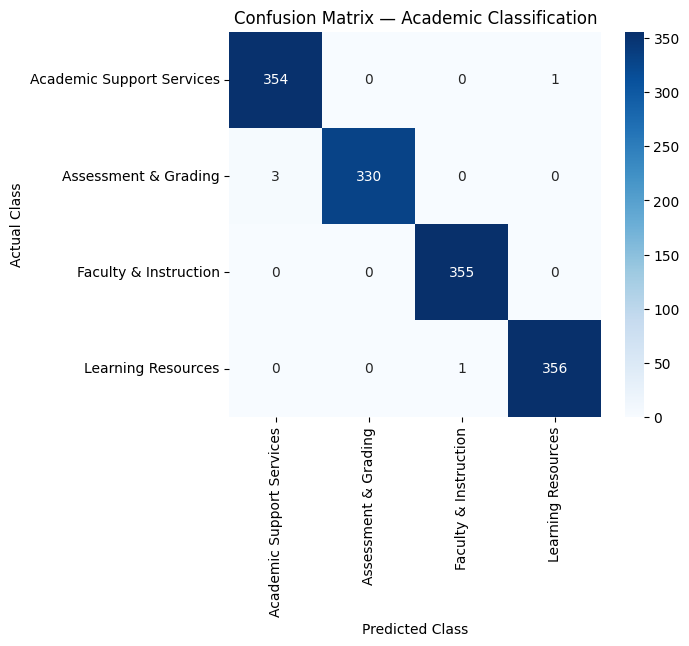

In [100]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — Academic Classification")

plt.show()

Evaluate Urgency Model

After training the urgency model.

In [101]:
urgency_predictions = urgency_trainer.predict(urgency_dataset)

y_pred = urgency_predictions.predictions.argmax(axis=1)
y_true = df["urgency_label"].values

Accuracy

In [102]:
print("Urgency Model Accuracy:", accuracy_score(y_true, y_pred))

Urgency Model Accuracy: 0.575813953488372


Confusion Matrix

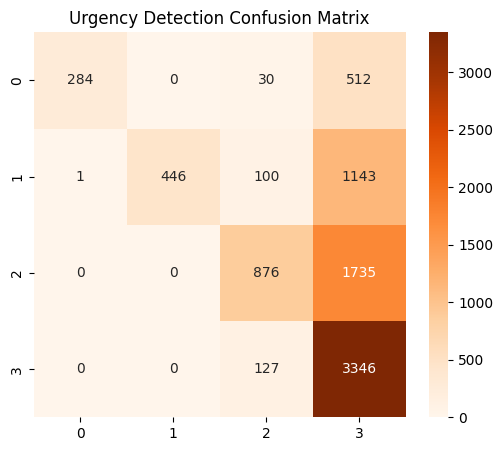

In [103]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Urgency Detection Confusion Matrix")

plt.show()

**52 — Train DistilBERT Sentiment Classifier**

Step 1 — Convert Sentiment Labels to Numbers

In [132]:
sentiment_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}


This converts sentiment categories into numbers so the model can learn them.

In [133]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,6901
Neutral,1234
Positive,465


This confirms the dataset contains all three sentiment classes.

Also Check Encoded Labels

In [134]:
df["sentiment_label"].value_counts()

,count
sentiment_label,
0,6901
1,1234
2,465


See Mixed Sentiments

In [135]:
df[["Sentiment","sentiment_label"]].sample(10)

,Sentiment,sentiment_label
3254,Neutral,1
7883,Negative,0
7504,Neutral,1
3880,Negative,0
6153,Negative,0
4139,Negative,0
5934,Negative,0
7377,Negative,0
8279,Negative,0
212,Negative,0


Tokenize Text for Sentiment Model

Use the cleaned complaint text.

In [136]:
sentiment_encodings = tokenizer(
    df["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

Create Sentiment Dataset

In [137]:
class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Create dataset:

In [138]:
sentiment_dataset = SentimentDataset(
    sentiment_encodings,
    df["sentiment_label"].tolist()
)

Load DistilBERT Sentiment Model

We use 3 labels.

In [139]:
sentiment_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train Sentiment Model

In [141]:
sentiment_trainer.train()

Step,Training Loss
500,0.218363
1000,0.206290
1500,0.197537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1614, training_loss=0.2062965816133823, metrics={'train_runtime': 424.0778, 'train_samples_per_second': 60.838, 'train_steps_per_second': 3.806, 'total_flos': 1000676574775296.0, 'train_loss': 0.2062965816133823, 'epoch': 3.0})

**53 — Detect Emotional Polarity**

Now the trained model predicts the sentiment of each complaint

Complaint:
"The professor grading is unfair"

Prediction:
Negative

In [142]:
sentiment_predictions = sentiment_trainer.predict(sentiment_dataset)

predicted_labels = sentiment_predictions.predictions.argmax(axis=1)

**54 — Assign Sentiment Score**

In [122]:
df["predicted_sentiment"] = predicted_labels

Convert numbers back to labels.

In [123]:
reverse_sentiment = {
    0:"Negative",
    1:"Neutral",
    2:"Positive"
}

df["predicted_sentiment_label"] = df["predicted_sentiment"].map(reverse_sentiment)

Now dataset contains:

| clean_text | Sentiment | predicted_sentiment_label |

**55 — Validate Sentiment Prediction Accuracy**

Evaluate model.

Check What Columns Exist

In [148]:
val_df.columns

Index(['Text', 'Academic Class', 'Urgency', 'Sentiment', 'Summary',
       'language'],
      dtype='object')

In [149]:
val_sentiment_encodings = tokenizer(
    val_df["Text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [152]:
val_sentiment_encodings = tokenizer(
    val_df["Text"].tolist(),   # change clean_text → Text
    truncation=True,
    padding=True,
    max_length=128
)

# Map the 'Sentiment' column in val_df to create 'sentiment_label'
val_df["sentiment_label"] = val_df["Sentiment"].map(sentiment_mapping)

val_sentiment_dataset = SentimentDataset(
    val_sentiment_encodings,
    val_df["sentiment_label"].tolist()
)

In [154]:
sentiment_trainer.train()

Step,Training Loss
500,0.201879
1000,0.195357
1500,0.188495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1614, training_loss=0.1947465386089339, metrics={'train_runtime': 338.6589, 'train_samples_per_second': 76.183, 'train_steps_per_second': 4.766, 'total_flos': 854429958604800.0, 'train_loss': 0.1947465386089339, 'epoch': 3.0})

In [163]:
from sklearn.metrics import accuracy_score, classification_report

predictions = sentiment_trainer.predict(val_sentiment_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = val_df["sentiment_label"].values

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Accuracy: 0.9292857142857143
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1117
           1       1.00      0.66      0.79       204
           2       1.00      0.63      0.78        79

    accuracy                           0.93      1400
   macro avg       0.97      0.76      0.84      1400
weighted avg       0.94      0.93      0.92      1400



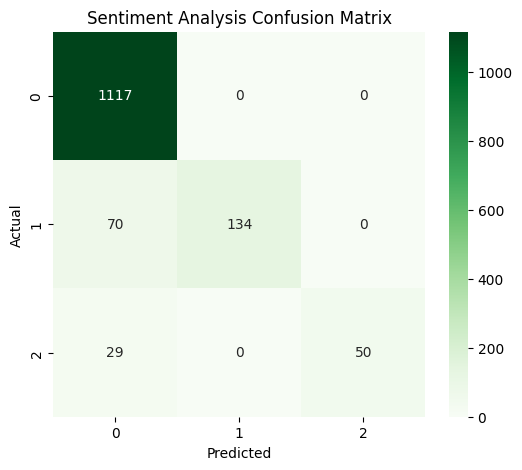

In [164]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis Confusion Matrix")

plt.show()

**Save the final dataset (Task 56):**

In [165]:
df.to_csv("/content/drive/MyDrive/iserve/final_dataset.csv", index=False)

In [166]:
# Academic Classification Model
model.save_pretrained("/content/drive/MyDrive/iserve/models/academic_classifier")
tokenizer.save_pretrained("/content/drive/MyDrive/iserve/models/academic_classifier")

# Urgency Model
urgency_model.save_pretrained("/content/drive/MyDrive/iserve/models/urgency_classifier")

# Sentiment Model
sentiment_model.save_pretrained("/content/drive/MyDrive/iserve/models/sentiment_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [167]:
# Path to the folder you want to download from Google Drive
# For example, to download the 'iserve' folder which contains all your models and data:
folder_to_download = "/content/drive/MyDrive/iserve"
output_zip_name = "iserve_contents.zip"

# Compress the folder into a zip file
# The -r flag is for recursive, meaning it includes all subdirectories and files.
!zip -r "{output_zip_name}" "{folder_to_download}"

# Import the files download utility
from google.colab import files

# Download the created zip file
files.download(output_zip_name)


  adding: content/drive/MyDrive/iserve/ (stored 0%)
  adding: content/drive/MyDrive/iserve/Training.csv (deflated 93%)
  adding: content/drive/MyDrive/iserve/.ipynb_checkpoints/ (stored 0%)
  adding: content/drive/MyDrive/iserve/language_test_set.csv (deflated 64%)
  adding: content/drive/MyDrive/iserve/Testing.csv (deflated 93%)
  adding: content/drive/MyDrive/iserve/Validation.csv (deflated 91%)
  adding: content/drive/MyDrive/iserve/test_bilingual.csv (deflated 92%)
  adding: content/drive/MyDrive/iserve/train_bilingual.csv (deflated 93%)
  adding: content/drive/MyDrive/iserve/val_bilingual.csv (deflated 91%)
  adding: content/drive/MyDrive/iserve/dataset_ready_for_training.csv (deflated 93%)
  adding: content/drive/MyDrive/iserve/final_dataset.csv (deflated 93%)
  adding: content/drive/MyDrive/iserve/models/ (stored 0%)
  adding: content/drive/MyDrive/iserve/models/academic_classifier/ (stored 0%)
  adding: content/drive/MyDrive/iserve/models/academic_classifier/config.json (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This code first creates a zip archive of your specified folder (`/content/drive/MyDrive/iserve`) and then triggers a download prompt in your browser for the `iserve_contents.zip` file. You can adjust the `folder_to_download` variable to target any other folder within your mounted Google Drive.